In [1]:
# File: 01_train_ddpm.ipynb

# %%
import torch
import matplotlib.pyplot as plt
from torchvision.utils import make_grid

from common import device, print_device, set_seed
from ddpm_lib import (
    DDPMPreconditioner,
    DiffusionSchedule,
    UNet28,
    get_ddpm_train_loader,
    train_ddpm,
    sample_ddpm_raw,
    save_ddpm_checkpoint,
)

print_device()


device: cuda
GPU Name: NVIDIA L40S


In [5]:
# %%
SEED = 2026
set_seed(SEED)

ROOT = "./data"
BATCH_SIZE = 128
DDPM_EPOCHS = 20


# user instructions: first run "identity" then run "M"
# PRECOND_MODE = "identity"
PRECOND_MODE = "M"          
M_PATH = "M_784.pt"



TARGET_STD = 1.0
T = 400
BETA_START = 1e-4
BETA_END = 0.02

MODEL_KWARGS = {"in_ch": 1, "base": 64, "temb_dim": 256}
DDPM_CKPT_PATH = f"ddpm_{PRECOND_MODE}_T{T}.pt"


Seed set to: 2026


In [6]:
# Helper code to load a random M (to avoid running algorithm)

#---Option 1--- (upper triangular ones)
# M = torch.ones((784,784),dtype=torch.float32).cpu()
# M = torch.triu(M)

#---Option 2--- (scaled identity)
# M = torch.eye(784, dtype=torch.float32).cpu() * 2000

#---Option 3--- variable identity
ones_tensor = torch.full((392,), 2.0, dtype=torch.float)
twos_tensor = torch.full((392,), 5.0, dtype=torch.float)
dg = torch.cat((ones_tensor, twos_tensor))
M = torch.diag(dg)

for i in range(783):
    M[i,783]=1
    M[i,0]=1
    M[783,i]=1
    M[0,i]=1


print(f"The size of M is {M.shape} and the datatype is {type(M)}")
torch.save(M, "M_784.pt")



M_load = torch.load("M_784.pt", map_location="cpu")
M_load

The size of M is torch.Size([784, 784]) and the datatype is <class 'torch.Tensor'>


tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 2., 0.,  ..., 0., 0., 1.],
        [1., 0., 2.,  ..., 0., 0., 1.],
        ...,
        [1., 0., 0.,  ..., 5., 0., 1.],
        [1., 0., 0.,  ..., 0., 5., 1.],
        [1., 1., 1.,  ..., 1., 1., 5.]])

In [7]:
# %%
precond = DDPMPreconditioner(
    mode=PRECOND_MODE,
    m_path=M_PATH,
    target_std=TARGET_STD,
    device=device,
)

pre_mean_cpu, pre_std_cpu = precond.fit_stats(root=ROOT, batch_size=512)
print("pre_mean:", float(pre_mean_cpu))
print("pre_std :", float(pre_std_cpu))

train_ds, train_loader = get_ddpm_train_loader(
    precond=precond,
    root=ROOT,
    batch_size=BATCH_SIZE,
    train=True,
    shuffle=True,
)

schedule = DiffusionSchedule(
    T=T,
    beta_start=BETA_START,
    beta_end=BETA_END,
    device=device,
)

ddpm = UNet28(**MODEL_KWARGS).to(device)


pre_mean: -6.030148029327393
pre_std : 29.401540756225586


In [8]:
# %%
ddpm = train_ddpm(
    model=ddpm,
    train_loader=train_loader,
    schedule=schedule,
    epochs=DDPM_EPOCHS,
    lr=1e-4,
    device=device,
)


[DDPM] Epoch 1/20: 100%|██████████| 468/468 [00:17<00:00, 26.34it/s, loss=0.0208]


[DDPM] Epoch 1: loss=0.0208


[DDPM] Epoch 2/20: 100%|██████████| 468/468 [00:17<00:00, 27.23it/s, loss=0.0157]


[DDPM] Epoch 2: loss=0.0157


[DDPM] Epoch 3/20: 100%|██████████| 468/468 [00:16<00:00, 27.61it/s, loss=0.0134]


...

[DDPM] Epoch 18: loss=0.0096


[DDPM] Epoch 19/20: 100%|██████████| 468/468 [00:16<00:00, 27.60it/s, loss=0.0092]


[DDPM] Epoch 19: loss=0.0092


[DDPM] Epoch 20/20: 100%|██████████| 468/468 [00:16<00:00, 27.62it/s, loss=0.0091]

[DDPM] Epoch 20: loss=0.0091


In [9]:
# %%
save_ddpm_checkpoint(
    path=DDPM_CKPT_PATH,
    model=ddpm,
    precond=precond,
    schedule=schedule,
    model_kwargs=MODEL_KWARGS,
)
print("saved:", DDPM_CKPT_PATH)


saved: ddpm_M_T400.pt


saved: ddpm_samples_raw_M.pt


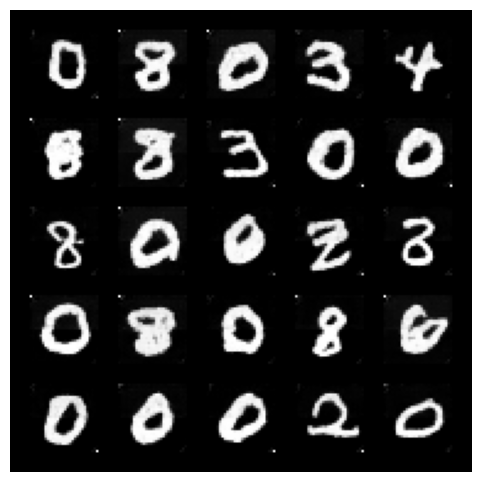

In [10]:
# %%
ddpm_samples_raw = sample_ddpm_raw(
    model=ddpm,
    schedule=schedule,
    precond=precond,
    n_samples=25,
    device=device,
)

torch.save(ddpm_samples_raw.cpu(), f"ddpm_samples_raw_{PRECOND_MODE}.pt")
print("saved:", f"ddpm_samples_raw_{PRECOND_MODE}.pt")

# %%
ddpm_samples_vis = (ddpm_samples_raw + 1.0) / 2.0
grid = make_grid(ddpm_samples_vis, nrow=5, padding=8)

plt.figure(figsize=(6, 6))
plt.axis("off")
plt.imshow(grid.permute(1, 2, 0).squeeze().cpu(), cmap="gray")
plt.show()
